<a href="https://colab.research.google.com/github/SimbakNetmind/machine-learnig-curos/blob/Machine_learning/01_B_Regresio_Lineal_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **01- Importar Librerias**

In [24]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12,12)
plt.rcParams['font.size'] = 16

# **02- Cargar DataFrame**

In [25]:
df = pd.read_csv("sample_data/vehiculos_procesado.csv",
                 usecols=["consumo", "co2", "cilindros","desplazamiento"])

print(f'Cantidad de filas: {df.shape[0]}')
print(f'Cantidad de columnas: {df.shape[1]}')
df.head(5)

Cantidad de filas: 35539
Cantidad de columnas: 4


,desplazamiento,cilindros,consumo,co2
0,2.5,4.0,17,522.764706
1,4.2,6.0,13,683.615385
2,2.5,4.0,16,555.437500
3,4.2,6.0,13,683.615385
4,3.8,6.0,16,555.437500


# **03- Copia de DataFrame**

In [26]:
vehiculos = df.copy()

# **04- Litros por Milla**

In [27]:

litros_por_galon =  3.78541
vehiculos["consumo_litros_milla"] = litros_por_galon/ vehiculos.consumo
vehiculos.head(5)

,desplazamiento,cilindros,consumo,co2,consumo_litros_milla
0,2.5,4.0,17,522.764706,0.222671
1,4.2,6.0,13,683.615385,0.291185
2,2.5,4.0,16,555.437500,0.236588
3,4.2,6.0,13,683.615385,0.291185
4,3.8,6.0,16,555.437500,0.236588


# **05- Datos de Entrenamiento**

In [28]:
pct_entrenamiento = 0.8
vehiculos_training = vehiculos.sample(frac=pct_entrenamiento)
vehiculos_test = vehiculos[~vehiculos.index.isin(vehiculos_training.index)]

print(f'Datos Entrenamiento: {vehiculos_training.shape}')
print(f'Datos Test: {vehiculos_test.shape}')

Datos Entrenamiento: (28431, 5)
Datos Test: (7108, 5)


# **06- Entrena un modelo de regresión lineal por Mínimos Cuadrados Ordinarios (OLS) utilizando la librería statsmodels**

In [29]:
modelo = smf.ols('co2 ~ consumo_litros_milla + cilindros + desplazamiento',
                  data=vehiculos_training).fit()

# **07- Extrae los coeficientes calculados por el modelo de StatsModels y los convierte en un diccionario de Python.**

In [30]:
model_params = modelo.params.to_dict()
model_params

{'Intercept': 10.446860493468506,
 'consumo_litros_milla': 2253.773800675846,
 'cilindros': -1.6505401181684036,
 'desplazamiento': 5.699522811581674}

# **08-Summary del Modelo**

In [33]:
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    co2   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 7.973e+05
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:47:41   Log-Likelihood:            -1.0938e+05
No. Observations:               28431   AIC:                         2.188e+05
Df Residuals:                   28427   BIC:                         2.188e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               10.4469      0.358     29.194      0.000       9.745      11.148
consumo_litros_milla  2253.7738      2.476    910.109      0.000    2248.920    2258.628
cilindros               -1.6505      0.093    -17.750      0.000      -1.833      -1.468
desplazamiento           5.6995      0.131     43.637      0.000       5.444       5.956
==============================================================================
Omnibus:                    11993.950   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          4802110.855
Skew:                          -0.714   Prob(JB):                         0.00
Kurtosis:                      66.653   Cond. No.                         259.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

09- Construye la representación textual de la ecuación del modelo insertando los parámetros almacenados en el diccionario model_params mediante desempaquetado de claves.
¿Qué hace cada parte?

    **model_params (Desempaquetado de diccionario):
    Pasa automáticamente las claves y valores del diccionario model_params a la función .format(). Es equivalente a escribir:

In [34]:
model_formula = "y ~ {Intercept:.3f} + {cilindros:.2f}*cilindros + {consumo_litros_milla:.2f}*consumo_litros_milla + {desplazamiento:.3f}*desplazamiento".format(
    **model_params)
model_formula

'y ~ 10.447 + -1.65*cilindros + 2253.77*consumo_litros_milla + 5.700*desplazamiento'

# **10- Grafica puntos de dispercion**

/tmp/ipykernel_941/3041150921.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


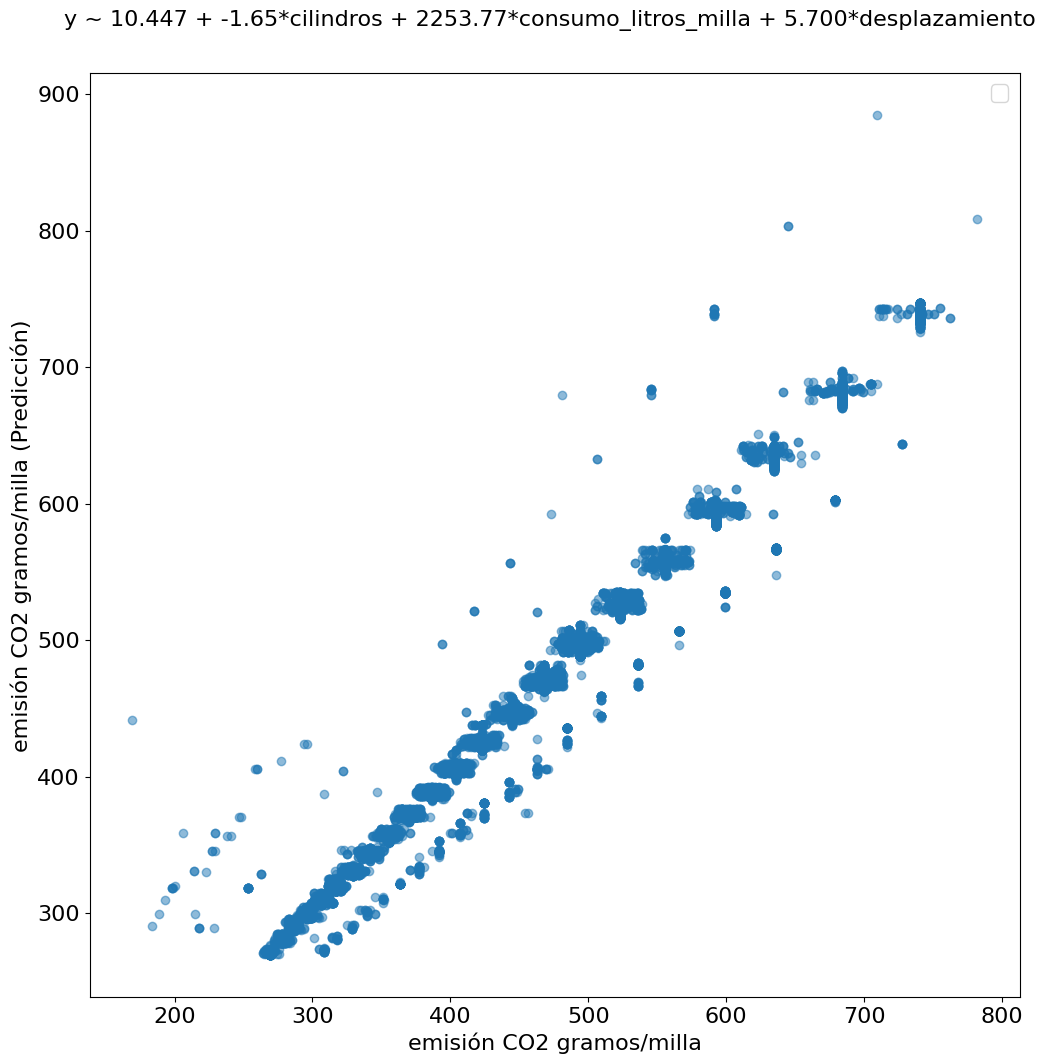

In [35]:
plt.scatter(vehiculos.co2, modelo.predict(vehiculos), alpha=0.5)
plt.text(120, 950, model_formula)
plt.xlabel("emisión CO2 gramos/milla")
plt.ylabel("emisión CO2 gramos/milla (Predicción)")
plt.legend();

# **11 - Funcion Para Predecir El Error Cuadratico Medio**

In [36]:
def error_cuadrático_medio(y, y_pred):
    return np.sum((y-y_pred)**2)/len(y)

In [39]:
# 1. Generar las predicciones sobre el conjunto de test
predicciones_test = modelo.predict(vehiculos_test)

# 2. Calcular el error cuadrático medio
error_test = error_cuadrático_medio(vehiculos_test.co2, predicciones_test)
error_test

np.float64(124.17864810697411)

# **Ejemplo con SkyLearn**

In [40]:
from sklearn.linear_model import LinearRegression

In [ ]:
variables_independientes = ['desplazamiento', 'cilindros','consumo_litros_milla']
variable_dependiente = 'co2'

X_training = vehiculos_training[variables_independientes]
y_training = vehiculos_training[variable_dependiente]
X_test = vehiculos_test[variables_independientes]
y_test = vehiculos_test[variable_dependiente]

In [ ]:
modelo = LinearRegression()

In [ ]:
modelo_entrenado = modelo.fit(X, y)

In [ ]:
y_pred = modelo_entrenado.predict(X_test)